## Setup and data load

In [1]:
import pandas as pd
import ir_datasets
from collections import Counter
import matplotlib.pyplot as plt
from IPython.display import display

# Load the Cranfield dataset using ir_datasets
dataset = ir_datasets.load("cranfield")

# Convert the dataset to pandas DataFrames for easier analysis
df_docs = pd.DataFrame(dataset.docs_iter())
df_queries = pd.DataFrame(dataset.queries_iter())
df_qrels = pd.DataFrame(dataset.qrels_iter())

In [2]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / "src").is_dir() and (project_root.parent / "src").is_dir():
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

from src.pre_processing import (
    PREPROCESSING_CONFIGS,
    build_all_configs,
    vocabulary_stats,
    save_preprocessed,
)

## Exploratory queries analysis

In [3]:
# Analyze the structure of the DataFrames
display(df_queries.head())

# Analyze the word length of the queries to support the critical analysis in the report
df_queries['words_length'] = df_queries['text'].apply(lambda x: len(x.split()))
display(df_queries['words_length'].describe())


,query_id,text
0,1,what similarity laws must be obeyed when const...
1,2,what are the structural and aeroelastic proble...
2,3,what problems of heat conduction in composite ...
3,4,can a criterion be developed to show empirical...
4,5,what chemical kinetic system is applicable to ...


count    225.000000
mean      17.973333
std        7.131995
min        6.000000
25%       13.000000
50%       17.000000
75%       22.000000
max       46.000000
Name: words_length, dtype: float64

## Exploratory qrels analysis (relevance)

In [4]:
# Analyze the distribution of relevance scores in the qrels DataFrame
display(df_qrels['relevance'].value_counts())

# Create a new column 'is_relevant' in the qrels DataFrame to indicate whether a document is relevant (1) or not (0) based on the relevance score
df_qrels['is_relevant'] = df_qrels['relevance'].apply(lambda x: 1 if x >= 1 else 0)

# Analyze the number of relevant documents per query
relevantes_por_query = df_qrels[df_qrels['is_relevant'] == 1].groupby('query_id').size()
print("\nRelevant documents per query:")
display(relevantes_por_query.describe())

relevance
 3    734
 2    387
 4    363
-1    225
 1    128
Name: count, dtype: int64


Relevant documents per query:


count    225.000000
mean       7.164444
std        5.388031
min        1.000000
25%        4.000000
50%        6.000000
75%        9.000000
max       39.000000
dtype: float64

In [5]:
# Analyze the number of relevant documents per query to identify queries with 2 or fewer relevant documents
qrels_relevants = df_qrels[df_qrels['is_relevant'] == 1]

# Count the number of relevant documents for each query
relevants_count = qrels_relevants.groupby('query_id').size()

# Identify queries with 2 or fewer relevant documents
dificult_queries = relevants_count[relevants_count <= 2]
print(f"Queries with 2 or fewer relevant documents: {len(dificult_queries)}")
display(dificult_queries.head())

Queries with 2 or fewer relevant documents: 35


query_id
103    2
112    2
117    2
119    1
123    2
dtype: int64

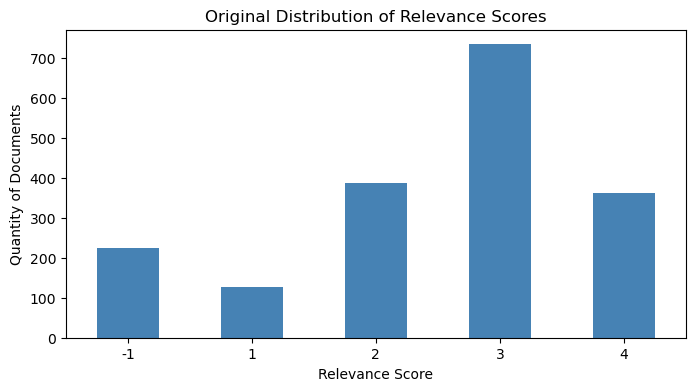

In [6]:
# Plot the original distribution of relevance scores
df_qrels['relevance'].value_counts().sort_index().plot(
    kind='bar', 
    color='steelblue', 
    figsize=(8, 4),
    title='Original Distribution of Relevance Scores'
)
plt.xlabel('Relevance Score')
plt.ylabel('Quantity of Documents')
plt.xticks(rotation=0)
plt.show()

## Exploratory documents analysis

In [7]:
# Analyze the structure of the documents DataFrame
display(df_docs.isna().sum())

# Analyze the length of the documents to support the critical analysis in the report
df_docs['text_length'] = df_docs['text'].apply(lambda x: len(str(x).split()))
print("\nStatistics of document lengths:")
display(df_docs['text_length'].describe())

doc_id    0
title     0
text      0
author    0
bib       0
dtype: int64


Statistics of document lengths:


count    1400.000000
mean      164.080000
std        88.695965
min         0.000000
25%        99.000000
50%       144.000000
75%       214.000000
max       669.000000
Name: text_length, dtype: float64

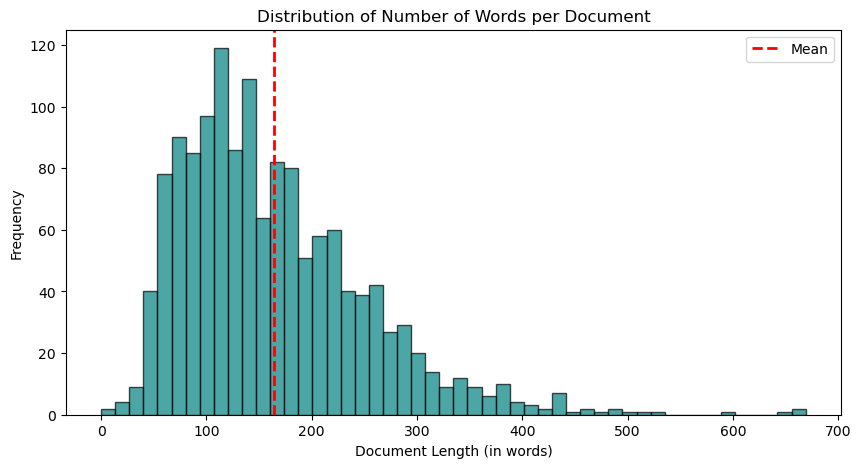

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df_docs['text_length'], bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(df_docs['text_length'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.title('Distribution of Number of Words per Document')
plt.xlabel('Document Length (in words)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Terms frequency analysis

In [9]:
# Union of all words in the documents, converted to lowercase and split into individual words
all_words = ' '.join(df_docs['text'].dropna()).lower().split()
words_count = Counter(all_words)

# Create a DataFrame to display the 20 most common words in the documents along with their frequencies
df_freq = pd.DataFrame(words_count.most_common(20), columns=['Termo', 'Frequência'])
display(df_freq)

,Termo,Frequência
0,the,19408
1,of,12597
2,.,9440
3,and,6085
4,a,5820
5,in,4579
6,to,4507
7,is,4068
8,for,3468
9,are,2415


In [10]:
df_docs['unique_words'] = df_docs['text'].dropna().apply(lambda x: set(str(x).lower().split()))
all_unique_words_per_doc = [word for doc_words in df_docs['unique_words'] for word in doc_words]
df_count = Counter(all_unique_words_per_doc)

df_document_frequency = pd.DataFrame(df_count.most_common(20), columns=['Term', 'DF (Document Count)'])
df_document_frequency['% of Corpus'] = (df_document_frequency['DF (Document Count)'] / len(df_docs)) * 100
print("\nTop 20 Terms with Highest Document Frequency (DF):")
display(df_document_frequency)


Top 20 Terms with Highest Document Frequency (DF):


,Term,DF (Document Count),% of Corpus
0,.,1398,99.857143
1,of,1394,99.571429
2,the,1391,99.357143
3,and,1320,94.285714
4,a,1300,92.857143
5,to,1250,89.285714
6,in,1240,88.571429
7,is,1147,81.928571
8,for,1143,81.642857
9,are,1026,73.285714


## Pre processing execution

In [11]:
# Build preprocessed data for all 4 configurations
print("Building preprocessed data for all 4 configurations...")
preprocessed_data = build_all_configs(df_docs, df_queries)
print("Done!")

Building preprocessed data for all 4 configurations...
Done!


## Pre processing results

In [12]:
# Example: inspect preprocessed output for the first document and first query
print("\nExample preprocessing for the first document:")
print(f"Original (raw): {df_docs.iloc[0]['title']} | {df_docs.iloc[0]['text'][:100]}...")
print(f"\nTokenized outputs:")
for config_name in PREPROCESSING_CONFIGS.keys():
    tokens = preprocessed_data[config_name]["docs"][0]
    print(f"  {config_name}: {tokens[:10]}... ({len(tokens)} tokens total)")

print("\n" + "="*80)
print("Example preprocessing for the first query:")
print(f"Original (raw): {df_queries.iloc[0]['text']}")
print(f"\nTokenized outputs:")
for config_name in PREPROCESSING_CONFIGS.keys():
    tokens = preprocessed_data[config_name]["queries"][0]
    print(f"  {config_name}: {tokens}")


Example preprocessing for the first document:
Original (raw): experimental investigation of the aerodynamics of a
wing in a slipstream . | experimental investigation of the aerodynamics of a
wing in a slipstream .
  an experimental study o...

Tokenized outputs:
  raw: ['experimental', 'investigation', 'of', 'the', 'aerodynamics', 'of', 'a', 'wing', 'in', 'a']... (146 tokens total)
  stopwords: ['experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream', 'experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream']... (80 tokens total)
  stemming: ['experiment', 'investig', 'of', 'the', 'aerodynam', 'of', 'a', 'wing', 'in', 'a']... (146 tokens total)
  stopwords_stemming: ['experiment', 'investig', 'aerodynam', 'wing', 'slipstream', 'experiment', 'investig', 'aerodynam', 'wing', 'slipstream']... (80 tokens total)

Example preprocessing for the first query:
Original (raw): what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed 

In [13]:
# Generate vocabulary statistics for each configuration
stats_list = []
for config_name, config_data in preprocessed_data.items():
    stats = vocabulary_stats(config_data["docs"])
    stats["Configuration"] = config_name
    stats_list.append(stats)

df_vocab_stats = pd.DataFrame(stats_list)
df_vocab_stats = df_vocab_stats[["Configuration", "vocabulary_size", "total_tokens", "avg_tokens_per_doc"]]
df_vocab_stats.columns = ["Configuration", "Vocabulary Size", "Total Tokens", "Avg Tokens/Doc"]

print("\nVocabulary Statistics by Configuration:")
display(df_vocab_stats)


Vocabulary Statistics by Configuration:


,Configuration,Vocabulary Size,Total Tokens,Avg Tokens/Doc
0,raw,6812,227377,162.412143
1,stopwords,6694,129134,92.238571
2,stemming,4226,227377,162.412143
3,stopwords_stemming,4116,129134,92.238571


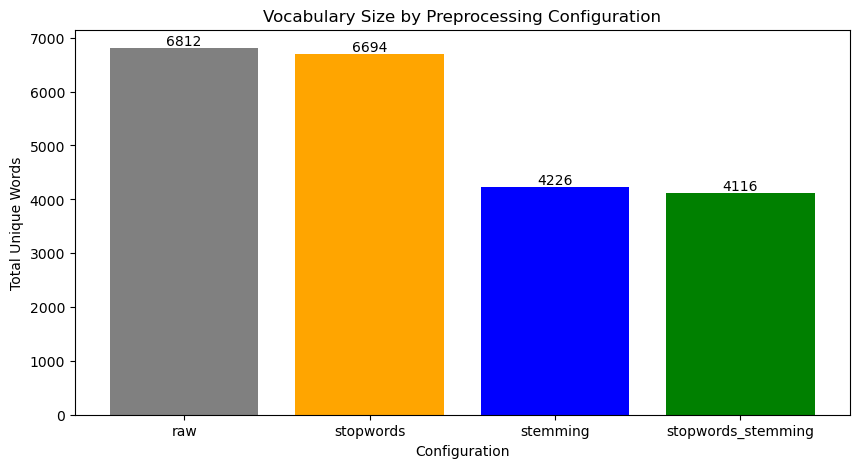

In [14]:
plt.figure(figsize=(10, 5))
bars = plt.bar(df_vocab_stats['Configuration'], df_vocab_stats['Vocabulary Size'], color=['gray', 'orange', 'blue', 'green'])
plt.title('Vocabulary Size by Preprocessing Configuration')
plt.ylabel('Total Unique Words')
plt.xlabel('Configuration')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')

plt.show()

In [15]:
# Save preprocessed data to disk for reuse in notebooks
output_dir = Path("../data/processed")
output_path = output_dir / "preprocessed_cranfield.pkl"

save_preprocessed(preprocessed_data, output_path)